# Neuro Spike Classifier
**Imelda Zahra Elnaz Putri** \
**1004306**

NOTE: The file `x.npy` is too large for GitHub (over 3GB) and has been excluded from the repository.
Please place your own `x.npy` file under the `data/` directory locally to run the notebook successfully.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Load the Data

In [14]:
# Load file
X = np.load('data/x.npy') # Spike train (samples x neurons x timesteps)
y = np.load('data/y.npy') # label

# Check the shape of the data
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (800, 1000, 501)
y shape: (800,)


## Visualization

### Heatmap spike train

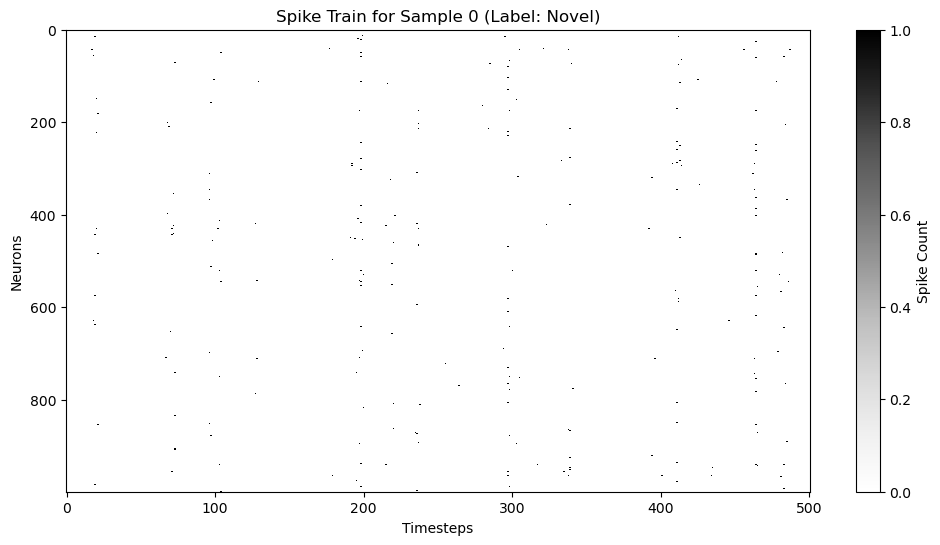

In [23]:
# Show spike train from one sample
sample_id = 0  # the index can be changed in order to look at different samples
sample = X[sample_id]  # shape: (neurons, timesteps)

plt.figure(figsize=(12, 6))
plt.imshow(sample, aspect='auto', cmap='Greys', interpolation='none')
plt.colorbar(label='Spike Count')
plt.title(f"Spike Train for Sample {sample_id} (Label: {'Familiar' if y[sample_id] == 1 else 'Novel'})")
plt.xlabel("Timesteps")
plt.ylabel("Neurons")
plt.show()

### Raster-like Plot (binary spikes)

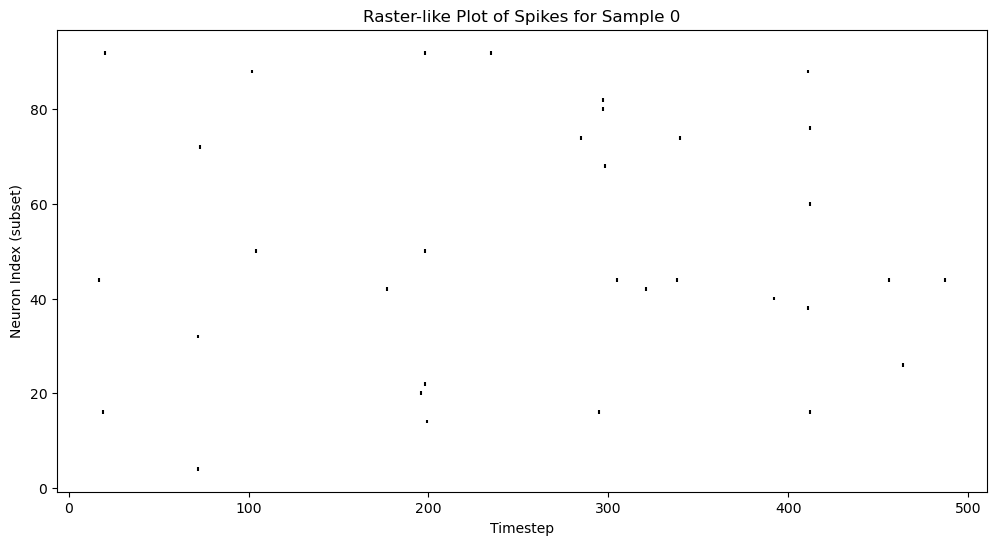

In [21]:
binary_sample = (sample > 0).astype(int)

plt.figure(figsize=(12, 6))
for neuron_idx in range(0, 100, 2):  # Plot subset (50 neurons) for clarity
    spike_times = np.where(binary_sample[neuron_idx] == 1)[0]
    plt.vlines(spike_times, neuron_idx - 0.4, neuron_idx + 0.4, color='black')

plt.title(f"Raster-like Plot of Spikes for Sample {sample_id}")
plt.xlabel("Timestep")
plt.ylabel("Neuron Index (subset)")
plt.show()

### Total spike count per neuron

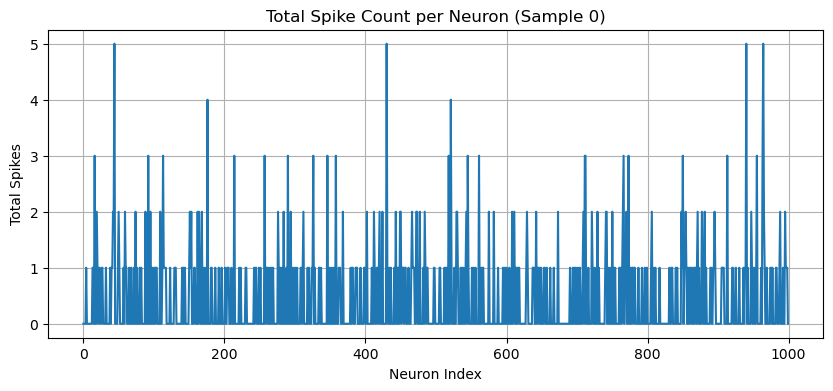

In [22]:
total_spikes = sample.sum(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(total_spikes)
plt.title(f"Total Spike Count per Neuron (Sample {sample_id})")
plt.xlabel("Neuron Index")
plt.ylabel("Total Spikes")
plt.grid(True)
plt.show()

## Feature Extraction

In [18]:
# Calculate firing rate per neuron (spikes per timestep)
X_rate = X.mean(axis=2)  # Shape: (samples, neurons)

print("X_rate shape:", X_rate.shape)

X_rate shape: (800, 1000)


## Exploratory Data Analysis

### Plot the distributions

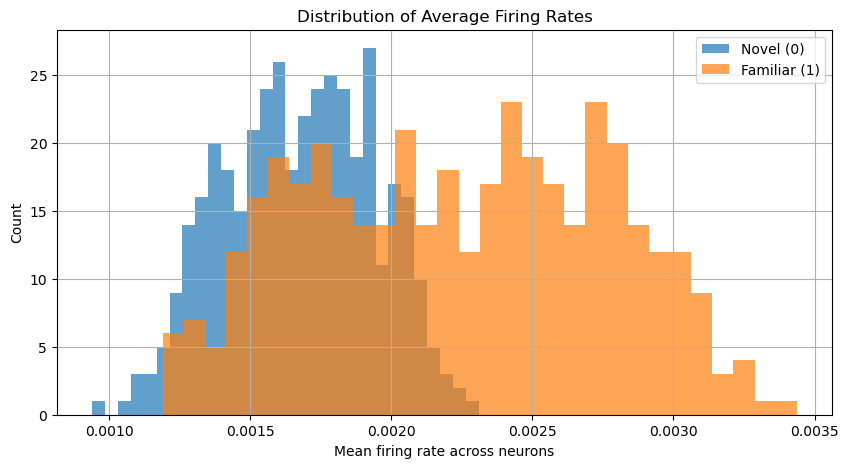

In [24]:
# Compare distributions of average firing rate
avg_firing_novel = X_rate[y == 0].mean(axis=1)
avg_firing_familiar = X_rate[y == 1].mean(axis=1)

# Plot average firing rate for familiar vs novel
plt.figure(figsize=(10,5))
plt.hist(avg_firing_novel, bins=30, alpha=0.7, label='Novel (0)')
plt.hist(avg_firing_familiar, bins=30, alpha=0.7, label='Familiar (1)')
plt.title("Distribution of Average Firing Rates")
plt.xlabel("Mean firing rate across neurons")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

### Measure the difference between the distributions
the absolute difference of means and standard deviation are used as simple, intuitive metrics to understand how much the average neural activity differs between classes.


In [35]:
# Mean difference and Standard Deviation
mean_novel = avg_firing_novel.mean()
mean_familiar = avg_firing_familiar.mean()
std_novel = avg_firing_novel.std()
std_familiar = avg_firing_familiar.std()
abs_diff = abs(mean_novel - mean_familiar)

print(f"Mean (Novel): {mean_novel:.4f}")
print(f"Mean (Familiar): {mean_familiar:.4f}")
print(f"Absolute Mean Difference: {abs_diff:.4f}")
print(f"Std (Novel): {std_novel:.4f}")
print(f"Std (Familiar): {std_familiar:.4f}")

Mean (Novel): 0.0017
Mean (Familiar): 0.0022
Absolute Mean Difference: 0.0006
Std (Novel): 0.0003
Std (Familiar): 0.0005


**Results**
- The average firing rate for novel stimuli is 0.0017, and for familiar stimuli is 0.0022.
- The absolute difference (0.0006) is relatively small, but considering the low magnitude of firing rates, this still might be meaningful.
- The standard deviations (0.0003 and 0.0005) suggest some overlap, but also some separation.

These findings indicate that although the two distributions are close, there may still be enough difference for a classifier to distinguish them.

## Model Training: Logistic regression


Logistic Regression is chosen because:
- This method is simple, quick to train, and easy to interpret.
- It is suitable as a baseline model for linear data such as firing rates.
- It does not overfit easily if the number of features and data is not too large.

In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rate, y, test_size=0.2, random_state=42)

In [32]:
# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Evaluation

In [51]:
# Evaluate Logistic Regression
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("[Logistic Regression Results]")
print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")

[Logistic Regression Results]
Accuracy: 0.569
F1 Score: 0.663


**Accuracy: 0.569** means that the model correctly predicts about 57% of the samples in the test data.

**F1 Score: 0.663** means a combination of precision and recall, which is significantly higher than accuracy.

Although the accuracy is only 56.9%, the F1 Score of 66.3% indicates that the model is fairly balanced in recognizing both classes (familiar and novel). This could occur if one class has an unbalanced distribution, or the model is better at recognizing one class than the other.

The F1 Score is more appropriate in this case because we are dealing with two classes that may have imbalance or be difficult to distinguish based on very small firing rates. Using firing rate as a feature still provides useful signals for classification, even though its performance is not yet optimal.

### Confusion Matrix
Shows the number of correct/incorrect predictions per class

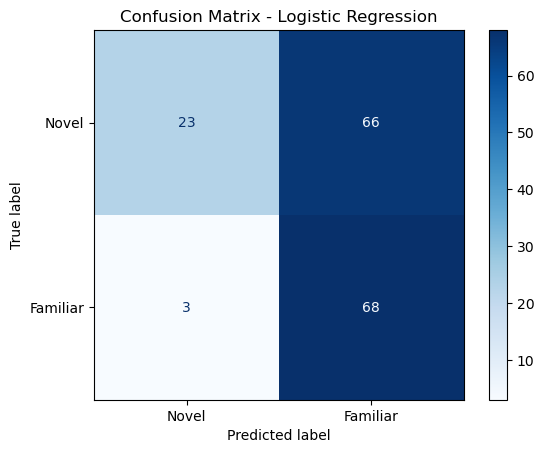

In [52]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Novel', 'Familiar'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Prediction Probability Histogram
Indicates how confident the model is about the predicted class

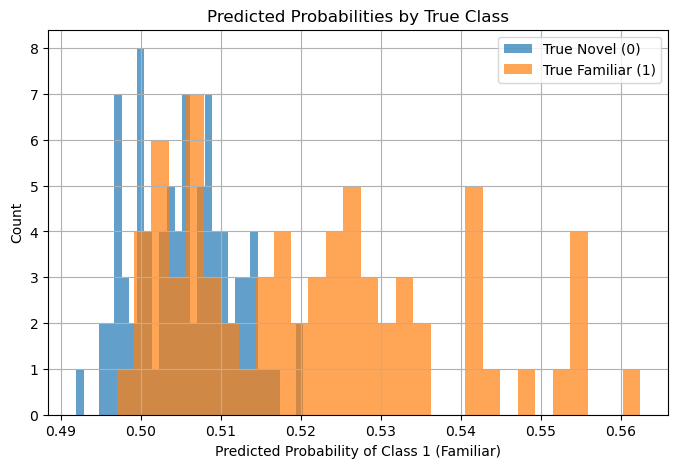

In [39]:
# Predicted probabilities by class
y_proba = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,5))
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.7, label='True Novel (0)')
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.7, label='True Familiar (1)')
plt.title('Predicted Probabilities by True Class')
plt.xlabel('Predicted Probability of Class 1 (Familiar)')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

### Distribution of Coefficients
Which neurons are most “influential” in classification

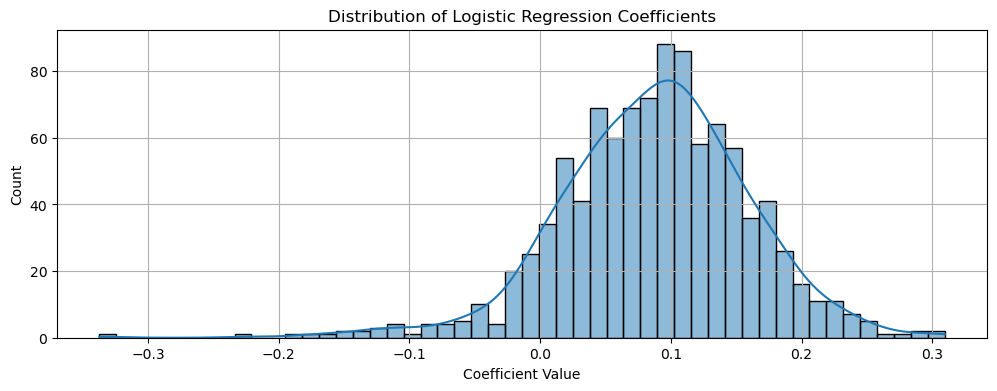

In [42]:
# Coefficient distribution (importance of neurons)
coeffs = model.coef_.flatten()
plt.figure(figsize=(12, 4))
sns.histplot(coeffs, bins=50, kde=True)
plt.title('Distribution of Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## Alternative model: Random Forest

Random Forest is chosen as a comparison model because:
- It is capable of capturing non-linear relationships between neurons and labels
- It does not require normalization or linearity assumptions
- It provides more balanced and accurate results
- It provides interpretation through feature importance

In [46]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("\n[Random Forest Results]")
print(f"Accuracy: {rf_acc:.3f}")
print(f"F1 Score: {rf_f1:.3f}")


[Random Forest Results]
Accuracy: 0.856
F1 Score: 0.835


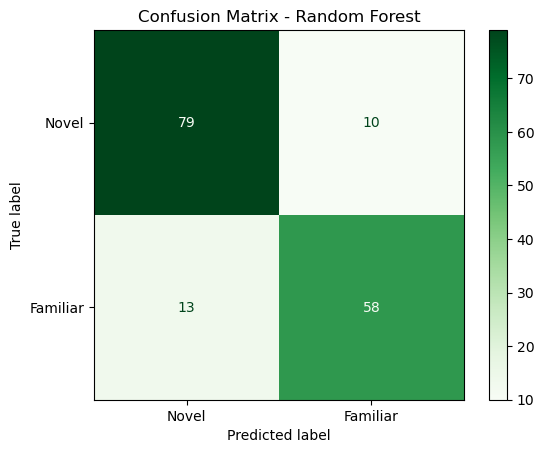

In [50]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Novel', 'Familiar'])
disp_rf.plot(cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.show()

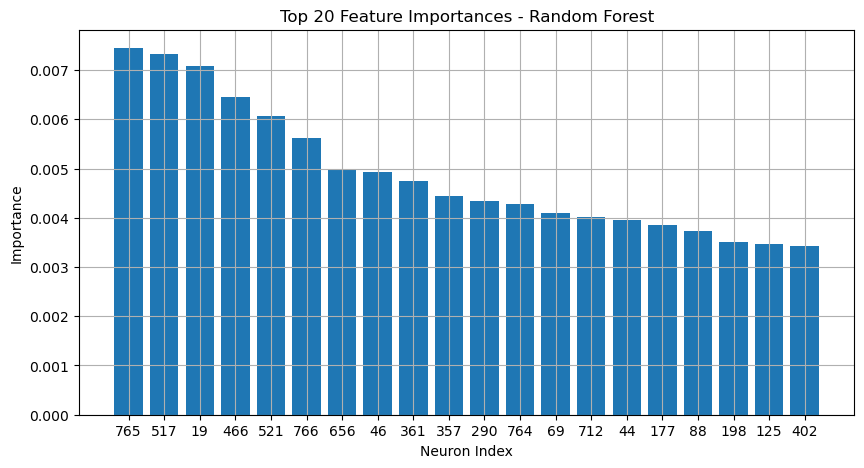

In [49]:
# Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:][::-1]  # Top 20 important features

plt.figure(figsize=(10, 5))
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), indices)
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Neuron Index")
plt.ylabel("Importance")
plt.grid(True)
plt.show()

## Model Comparison: Logistic Regression vs Random Forest
### Logistic Regression
**Accuracy**: 56.9% \
**F1 Score**: 66.3% \
**Confusion Matrix**: Familiar classified very well (68 correct, only 3 incorrect). However, most novel cases were incorrectly classified as familiar (66 incorrect, only 23 correct) \
**Conclusion**: This model is overly biased toward classifying all inputs as familiar. This is common in linear models when features are insufficient to distinguish between the two classes.

### Random Forest
**Accuracy**: 85.6% \
**F1 Score**: 83.5% \
**Confusion Matrix**: Both balanced: 79 novel correct, 58 familiar correct. Only a few classification errors in both classes \
**Conclusion**: Random Forest is much better at recognizing both classes in a balanced manner. This indicates that non-linear models like RF can capture patterns not detected by Logistic Regression.
